# Projekt zaliczeniowy - SGGW Uczenie maszynowe

## Semantyczna Klasyfikacja Pozycji Paragonowych (Food vs. Drinks)

### [Opis projektu w pliku .md](./SGGW_Uczenie_maszynowe_projekt_zadanie_1.md)

### 1. Import bibliotek

In [1]:
import csv
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import random
from pprint import pprint
from pathlib import Path
from tqdm import tqdm
from datasets import load_dataset, load_from_disk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

### 2. Wczytanie danych

Użyto danych CORD-v2 dostępnych na https://huggingface.co/datasets/naver-clova-ix/cord-v2

In [ ]:
# Wczytanie danych z dysku jeśli istnieją, jeśli nie to pobierz ze strony huggingface
if Path("cord-v2-dataset").exists():
    dataset = load_from_disk("cord-v2-dataset")
else:
    dataset = load_dataset("naver-clova-ix/cord-v2")
    dataset.save_to_disk("cord-v2-dataset")  # Zapisz dane na dysku na przyszłość

Saving the dataset (0/4 shards):   0%|          | 0/800 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

In [3]:
# Podejrzenie jak wyglądają dane
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
})


Dane są dostępne do podejrzenia w repozytorium CORD-v2 na Hugging Face. Dla uproszczenia przykładowe dane dla zdjęcia o ID 6 zostały zapisane w pliku [sample_image.json](sample_image.json).  
Dane które nas interesują to wartości "nm" w sekcji "ground_truth".  
"ground_truth": {  
&emsp;&emsp;"gt_parse": {  
&emsp;&emsp;&emsp;&emsp;"menu": [  
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;{  
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;"nm": ""  
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;}]  
&emsp;&emsp;&emsp;&emsp;}  
&emsp;&emsp;}

In [4]:
def extract_product_names_from_record(record):
    """Funkcja pomocnicza do wyciągnięcia nazw produktów z rekordu."""
    try:
        # Parsujemy string JSON z kolumny 'ground_truth'
        data = json.loads(record['ground_truth'])

        # Nawigujemy po strukturze: gt_parse -> menu
        menu_items = data.get('gt_parse', {}).get('menu', [])

        # Wyciągamy 'nm' (nazwę) z każdego elementu menu i zwracamy listę nazw produktów
        return [item.get('nm') for item in menu_items if 'nm' in item]
    except (json.JSONDecodeError, TypeError, AttributeError):
        return []

In [ ]:
# Iterujemy po datasecie i zbieramy wyniki do listy
all_product_names = []

datasets = ['train', 'test', 'validation']

for dataset_name in datasets:
    for record in tqdm(dataset[dataset_name]):
        names = extract_product_names_from_record(record)
        all_product_names.extend(names)

# Wyświetlamy wynik
print(f"Znaleziono {len(all_product_names)} nazw produktów.")
print("Pierwsze 5 nazw produktów:", all_product_names[:5])

100%|██████████| 100/100 [00:02<00:00, 34.37it/s]

Znaleziono 2142 nazw produktów.
Pierwsze 5 nazw produktów: ['Nasi Campur Bali', 'Bbk Bengil Nasi', 'MilkShake Starwb', 'Ice Lemon Tea', 'Nasi Ayam Dewata']


In [6]:
# Sprawdzam czy wszystkie elementy listy są stringami:
for i in range(len(all_product_names)):
    if type(all_product_names[i]) != str:
        print(i, all_product_names[i])

2031 ['-', 'Gyro Platter Regular']


In [7]:
# Generator który spłaszcza listę (usuwa listy wewnętrzne):
def flatten_product_list(data):
    for item in data:
        if isinstance(item, list):
            yield from item
        else:
            yield item

In [ ]:
# Nadpisujemy zmienną nową, naprawioną listą
all_product_names = list(flatten_product_list(all_product_names))
# Tworzymy set z listy by usunąć duplikaty i zamieniamy z powrotem na listę
all_product_names = list(set(all_product_names))
print(f"Liczba unikalnych produktów: {len(all_product_names)}")

Liczba unikalnych produktów: 1506


In [9]:
# zapisujemy do pliku wszystkie nazwy produktów
csv_file = 'csv_files/all_product_names.csv'

with open(csv_file, 'w', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(["product_name"])

    for name in all_product_names:
        writer.writerow([name])

### 3. EDA

Ponieważ dane w CORD nie posiadają kategorii produktu, które można wykorzystać do klasyfikacji, stworzyłem nowy plik all_product_names_cat.csv, w którym do każdej pozycji przypisałem kategorię "FOOD", "DRINK" lub "OTHER". Wykorzystałem do tego zadania Gemini 3 Pro.

In [10]:
df = pd.read_csv("csv_files/all_product_names_cat.csv")
df.head(10)

,product_name,label
0,BEEF CURRYRICE,FOOD
1,RB. AI-AI CHOCO,FOOD
2,NASI LIWET,FOOD
3,BAKWAN JAGUNG,FOOD
4,Ice Orange,DRINK
5,RENDANG OMURICE,FOOD
6,Lasagna,FOOD
7,Astor Stick Cokelat 40gr,FOOD
8,MARBLED SIRLOIN STEAK 200gr,FOOD
9,HAI CMP SPC,FOOD


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_name  1506 non-null   object
 1   label         1506 non-null   object
dtypes: object(2)
memory usage: 23.7+ KB


In [12]:
# Usuwam zbędne spacje
df['product_name'] = df['product_name'].str.strip()

In [13]:
# Usuwam wiersze które mają mniej niż 2 znaki
df = df[df['product_name'].str.len() >= 2]

In [ ]:
# Usuwam wiersze które składają się tylko z cyfr
def has_letters(text):
    return bool(re.search('[a-zA-Z]', text))

df = df[df['product_name'].apply(has_letters)]

In [15]:
df.label.value_counts()

label
FOOD     1050
DRINK     322
OTHER     132
Name: count, dtype: int64

Ponieważ klasy są niezbalansowane, należy sprawdzić czy nie zaburzy to wyników. W tym celu zostanie zastosowana augmentacja wyników. By być pewnym, że daje ona pozytywne wyniki, najpierw model wytrenujemy na zbiorze bez augmentacji, a następnie na zbiorze z augmentacją.

Duplikaty zostały usunięte wcześniej poprzez użycie set().

In [16]:
# Zapisuję oczyszczone dane do pliku
cleaned_data_name = 'csv_files/labeled_products_cleaned.csv'
df.to_csv(cleaned_data_name, index=False)
print(f"Zapisano oczyszczone dane do pliku: {cleaned_data_name}")

Zapisano oczyszczone dane do pliku: csv_files/labeled_products_cleaned.csv


### 4. Modelowanie

In [17]:
# df = pd.read_csv('csv_files/labeled_products_cleaned.csv') # wczytanie danych z pliku
df.head(11)

,product_name,label
0,BEEF CURRYRICE,FOOD
1,RB. AI-AI CHOCO,FOOD
2,NASI LIWET,FOOD
3,BAKWAN JAGUNG,FOOD
4,Ice Orange,DRINK
5,RENDANG OMURICE,FOOD
6,Lasagna,FOOD
7,Astor Stick Cokelat 40gr,FOOD
8,MARBLED SIRLOIN STEAK 200gr,FOOD
9,HAI CMP SPC,FOOD


In [18]:
# Mapowanie etykiet tekstowych na liczby
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

In [19]:
df.head(11)

,product_name,label
0,BEEF CURRYRICE,1
1,RB. AI-AI CHOCO,1
2,NASI LIWET,1
3,BAKWAN JAGUNG,1
4,Ice Orange,0
5,RENDANG OMURICE,1
6,Lasagna,1
7,Astor Stick Cokelat 40gr,1
8,MARBLED SIRLOIN STEAK 200gr,1
9,HAI CMP SPC,1


LabelEncoder() przypisał numery etykiet do kolumny label zgodnie z kolejnością alfabetyczną, czyli:
- 0 -> DRINK
- 1 -> FOOD
- 2 -> OTHER

In [20]:
# Podział danych na zbiór treningowy i testowy z użyciem stratify by zachować proporcję klas
# (gwarantuje, że proporcje klas są zachowane w zbiorach treningowym i testowym)
X_train, X_test, y_train, y_test = train_test_split(df['product_name'],
                                                    df['label'],
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=df['label'])

In [21]:
# Podgląd proporcji klas w zbiorach treningowym i testowym
print("Drink: 0, Food: 1, Other: 2")
print("train: ", y_train.value_counts().sort_index(), "\n")
print("test: ", y_test.value_counts().sort_index())

Drink: 0, Food: 1, Other: 2
train:  label
0    257
1    840
2    106
Name: count, dtype: int64 

test:  label
0     65
1    210
2     26
Name: count, dtype: int64


In [22]:
# Zapisanie zbiorów do plików
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

train_df.to_csv('csv_files/train.csv', index=False)
test_df.to_csv('csv_files/test.csv', index=False)

### 5. Trenowanie modelu
Ponieważ w danych posiadam mieszankę języków, decyduje się na użycie modelu wielojęzycznego - DistilBERT Multilingual.

In [23]:
class ModelTrainer:
    """
    Klasa obudowująca (wrapper) proces trenowania i ewaluacji modelu transformerów.
    Klasa ta zarządza całym cyklem życia modelu: od wczytania danych i tokenizacji,
    przez inicjalizację modelu, aż po trening, ewaluację i zapisanie wyników.
    """

    def __init__(self, model_name, num_epochs, batch_size, train_file, test_file, labels_map):
        self.model_name = model_name
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.train_file = train_file
        self.test_file = test_file

        # Konwersja mapowania etykiet
        self.label2id = labels_map
        self.id2label = {v: k for k, v in labels_map.items()}
        self.num_labels = len(labels_map)

        # Placeholdery na obiekty tworzone później
        self.tokenized_datasets = None
        self.tokenizer = None
        self.trainer = None

    def tokenize_data(self, max_length=64):
        """Wczytuje zbiór danych i przeprowadza tokenizację przy użyciu tokenizera modelu."""
        # Inicjalizacja tokenizera
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)

        # Wczytanie danych z pliku CSV
        dataset = load_dataset("csv", data_files={"train": self.train_file, "test": self.test_file})

        # Funkcja tokenizująca
        def _tokenize_function(examples):
            """Padding='max_length' wyrównuje wszystkie zdania do tej samej długości,
                        dodaje puste tokeny dla krótszych zdań
            Truncation=True ucina zbyt długie zdania
            """
            return self.tokenizer(examples["text"], padding="max_length", truncation=True, max_length=max_length)
        
        self.tokenized_datasets = dataset.map(_tokenize_function, batched=True)

    def train_model(self):
        """
        Uruchamia pełny proces treningu modelu.
        
        Inicjalizuje model, konfiguruje argumenty treningowe, uruchamia trening,
        a na końcu przeprowadza ewaluację na zbiorze testowym.
        """

        if self.tokenized_datasets is None:
            print("Tokenized datasets nie zostały zainicjalizowane. Uruchom .tokenize_data().")
            return

        model = self._prepare_model()
        training_args = self._prepare_training_args()
        self.trainer = self._prepare_trainer(model, training_args)

        print("Rozpoczynam trening...")
        self.trainer.train()

        print("\nEwaluacja końcowa na zbiorze testowym:")
        results = self.trainer.evaluate()
        pprint(results)

    def save_model(self, output_dir):
        if self.trainer is None:
            print("Trainer nie został zainicjalizowany. Uruchom .train_model().")
            return

        self.trainer.save_model(output_dir)
        self.tokenizer.save_pretrained(output_dir)
        print(f"Model zapisany w folderze: {output_dir}")

    def load_saved_model(self, model_path):
        """
        Wczytuje zapisany model i przygotowuje go do predykcji/ewaluacji (bez treningu).
        """
        print(f"Wczytywanie modelu z: {model_path} ...")
        self.model_name = model_path
        
        # Jeśli jeszcze nie stokenizowano danych, zrób to teraz 
        # (użyje tokenizera z wczytanego folderu modelu)
        if self.tokenized_datasets is None:
            self.tokenize_data()
            
        model = self._prepare_model()
        training_args = self._prepare_training_args()
        
        # Inicjalizujemy trenera, ale NIE uruchamiamy .train()
        self.trainer = self._prepare_trainer(model, training_args)
        print("Model wczytany pomyślnie. Możesz teraz użyć .plot_confusion_matrix()")

    def plot_confusion_matrix(self):
        """Wyświetla macierz pomyłek (confusion matrix) dla modelu."""
        if self.trainer is None or self.tokenized_datasets is None:
            print("Model nie został wytrenowany.")
            return

        predictions_output = self.trainer.predict(self.tokenized_datasets["test"])
        preds = np.argmax(predictions_output.predictions, axis=-1)
        labels = predictions_output.label_ids

        # Przygotowanie nazw klas w odpowiedniej kolejności (według ID)
        # Sortujemy słownik id2label po kluczach (0, 1, 2...)
        sorted_ids = sorted(self.id2label.keys())
        target_names = [self.id2label[i] for i in sorted_ids]

        # Raport tekstowy
        print("\n=== SZCZEGÓŁOWY RAPORT KLASYFIKACJI ===")
        print(classification_report(labels, preds, target_names=target_names))

        # Macierz pomyłek
        cm = confusion_matrix(labels, preds)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=target_names, yticklabels=target_names)
        plt.xlabel('Model Przewidział')
        plt.ylabel('Prawda (Zbiór Testowy)')
        plt.title('Macierz Pomyłek (Confusion Matrix)')
        plt.show()

    def _compute_metrics(self, eval_pred):
        """Oblicza metryki (Accuracy i F1-Score) podczas ewaluacji."""
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        
        # Używamy F1 Macro ze względu na niezbalansowane klasy
        acc = accuracy_score(labels, predictions)
        f1 = f1_score(labels, predictions, average='macro')
        
        return {"accuracy": acc, "f1": f1}

    def _prepare_model(self):
        model = AutoModelForSequenceClassification.from_pretrained(
            self.model_name, 
            num_labels=self.num_labels, 
            id2label=self.id2label, 
            label2id=self.label2id
        )
        return model
        
    def _prepare_training_args(self):
        # Tworzenie nazw katalogów
        safe_name = self.model_name.replace('/', '_')
        train_file_name = Path(self.train_file).stem
        test_file_name = Path(self.test_file).stem

        output_dir = f"./results/{safe_name}_bs{self.batch_size}_ep{self.num_epochs}_{train_file_name}_{test_file_name}"
        
        training_args = TrainingArguments(
            output_dir=output_dir,
            eval_strategy="epoch",          # Sprawdzaj wyniki co epokę
            save_strategy="epoch",          # Zapisuj model co epokę
            learning_rate=2e-5,             # Standardowa prędkość uczenia dla BERTa
            per_device_train_batch_size=self.batch_size,
            per_device_eval_batch_size=self.batch_size,
            num_train_epochs=self.num_epochs,
            weight_decay=0.01,              # Regularyzacja
            load_best_model_at_end=True,    # Na koniec wczytaj najlepszą wersję
            metric_for_best_model="f1",     # Najlepszy model to ten z najwyższym F1
            report_to="none"                # Wyłącz raportowanie do wandb
        )
        return training_args
    
    def _prepare_trainer(self, model, training_args):
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=self.tokenized_datasets["train"],
            eval_dataset=self.tokenized_datasets["test"],
            compute_metrics=self._compute_metrics,
        )
        return trainer

In [25]:
# Etykiety
labels_map = {"DRINK": 0, "FOOD": 1, "OTHER": 2}

# Inicjalizacja modelu
distilbert_model = ModelTrainer(
    model_name="distilbert-base-multilingual-cased",
    num_epochs=10,
    batch_size=16,
    train_file="csv_files/train.csv",
    test_file="csv_files/test.csv",
    labels_map=labels_map
)

In [26]:
# Tokenizacja danych
distilbert_model.tokenize_data()

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1203 [00:00<?, ? examples/s]

Map:   0%|          | 0/301 [00:00<?, ? examples/s]

In [27]:
# Trening modelu
distilbert_model.train_model()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Rozpoczynam trening...


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.658260,0.757475,0.432794
2,No log,0.519367,0.823920,0.601810
3,No log,0.470393,0.820598,0.681091
4,No log,0.479361,0.847176,0.728122
5,No log,0.570492,0.837209,0.751813
6,No log,0.608719,0.843854,0.775050
7,0.321600,0.604517,0.860465,0.777154
8,0.321600,0.643839,0.860465,0.775398
9,0.321600,0.662736,0.850498,0.766489
10,0.321600,0.654970,0.857143,0.776404


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\R


Ewaluacja końcowa na zbiorze testowym:


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'epoch': 10.0,
 'eval_accuracy': 0.8604651162790697,
 'eval_f1': 0.7771538821478249,
 'eval_loss': 0.6045166254043579,
 'eval_runtime': 6.2589,
 'eval_samples_per_second': 48.092,
 'eval_steps_per_second': 3.036}


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



=== SZCZEGÓŁOWY RAPORT KLASYFIKACJI ===
              precision    recall  f1-score   support

       DRINK       0.85      0.71      0.77        65
        FOOD       0.87      0.94      0.91       210
       OTHER       0.75      0.58      0.65        26

    accuracy                           0.86       301
   macro avg       0.82      0.74      0.78       301
weighted avg       0.86      0.86      0.86       301



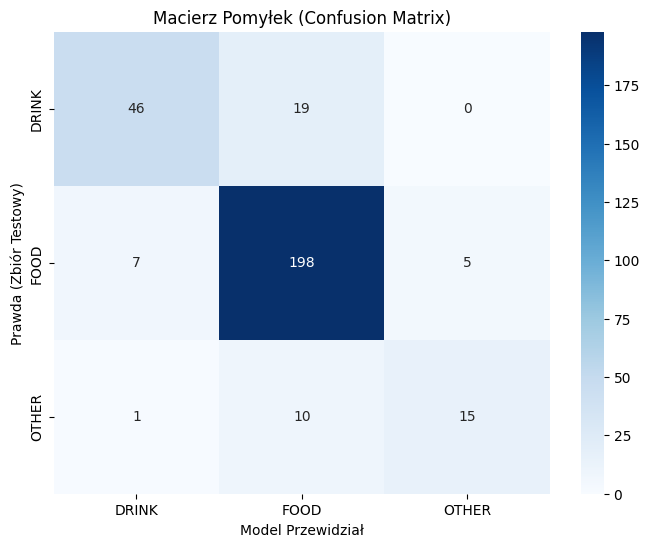

In [28]:
# Raport klasyfikacji
distilbert_model.plot_confusion_matrix()

In [29]:
# Zapisanie modelu
distilbert_model.save_model("./Models/distilbert_model_no_augmentation")

Model zapisany w folderze: ./Models/distilbert_model_no_augmentation


#### Analiza wyników:  
Na podstawie wyników można stwierdzić, że ograniczeniem w trenowaniu modelu jest brak odpowiednich danych do nauki. Pomimo tego, że model jest w stanie osiągnąć dobre wyniki w porównaniu do losowego modelu, to widać dwa podstawowe problemy: Niezbalansowane klasy oraz Overfitting.

1. Problem Przeuczenia (Overfitting)
Patrząc na wyniki Validation Loss widać, że już po 3 epoce zaczyna rosnąć:
- epoka 7 (z najlepszym wynikiem F1): 0,6045 (wzrost o 28% względem minimum)
- epoka 10: 0,6549 (wzrost o 39% względem minimum)
Powyższe wyniki pokazują, że model ma problem z radzeniem sobie z nowymi danymi.

2. Problem niezbalansowanych klas
Porównując wyniki recall dla każdej klasy można zauważyć, problem niezbalansowanych klas (840 Food vs 257 Drink vs 106 Other):
- FOOD: 94% - Model prawie nie myli jedzenia, czyli przyjął strategię "Jak nie jestem pewien, to strzelam, że to jedzenie"
- DRINK: 71% - Model przeoczył prawie 30% wyników - słaby wynik, zwłaszcza jeśli porówna się go do wyników FOOD
- OTHER: 58% - Model zgaduje niewiele lepiej niż rzut monetą

3. Złudne Accuracy
Wysokie Accuracy na poziomie 86% pokazuje, że model jest w stanie osiągnąć dobre wyniki w porównaniu do losowego modelu, ale to tylko maska. Ponieważ większość danych to FOOD, model nauczył się bezpiecznej strategii strzelając w FOOD jeśli nie jest pewny. Dlatego do oceny modelu użyliśmy metryki F1 score (77%).

### 6. Augmentacja danych treningowych
Z powodu nie zbalansowania danych treningowych, należy zastosować technikę augmentacji danych treningowych i porównać wyniki modelu z i bez augmentacji.

In [ ]:
# 1. Wczytanie zbioru treningowego
df = pd.read_csv('csv_files/train.csv')

print(f"Liczba wierszy przed augmentacją: {len(df)}")
print("Rozkład klas przed:", df['label'].value_counts().to_dict())

# Słowniki do augmentacji
# label: 0 to DRINK
drink_prefixes = ["Ice ", "Hot ", "Cold ", "Fresh ", "Sweet ", "Large ", "Small ", "1x ", "Es ", "Teh ", "Jus "]
drink_suffixes = [" (L)", " (M)", " Bottle", " Cup", " Dingin", " Panas", " Special", " 330ml"]

# label: 2 to OTHER
other_prefixes = ["1pc ", "Extra ", "Add ", "Plastic ", "Charge ", "Fee ", "Tax "]
other_suffixes = [" Bag", " Service", " Charge", " Fee", " Only", " (Small)"]

new_rows = []

# Iterujemy po wierszach
for index, row in df.iterrows():
    text = str(row['text'])
    label = row['label']
    
    # === AUGMENTACJA NAPOJÓW (Klasa 0) ===
    # Chcemy ich dużo więcej, więc dla każdego napoju generujemy 2-3 nowe wersje
    if label == 0:
        # Wersja 1: Prefiks
        new_rows.append({'text': random.choice(drink_prefixes) + text, 'label': 0})
        # Wersja 2: Sufiks
        new_rows.append({'text': text + random.choice(drink_suffixes), 'label': 0})
        # Wersja 3: Uppercase (czasem paragony są drukowane wielkimi literami)
        if random.random() > 0.5:
            new_rows.append({'text': text.upper(), 'label': 0})

    # === AUGMENTACJA OTHER (Klasa 2) ===
    elif label == 2:
        # Dla 'Other' też dodajemy warianty
        new_rows.append({'text': random.choice(other_prefixes) + text, 'label': 2})
        new_rows.append({'text': text + random.choice(other_suffixes), 'label': 2})

# Tworzymy DataFrame z nowymi danymi
df_aug = pd.DataFrame(new_rows)

# Łączymy ze starym zbiorem treningowym
df_final = pd.concat([df, df_aug], ignore_index=True)

# Mieszamy (shuffle)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print("-" * 30)
print(f"Liczba wierszy po augmentacji: {len(df_final)}")
print("Rozkład klas po:", df_final['label'].value_counts().to_dict())

# Zapisujemy nowy plik treningowy
augmented_file_path = 'csv_files/train_augmented.csv'
df_final.to_csv(augmented_file_path, index=False)
print("Zapisano: ", augmented_file_path)

### Trenowanie modelu na danych augmentowanych

In [32]:
# Etykiety
labels_map = {"DRINK": 0, "FOOD": 1, "OTHER": 2}

# Inicjalizacja modelu
distilbert_model_augmented = ModelTrainer(
    model_name="distilbert-base-multilingual-cased",
    num_epochs=10,
    batch_size=16,
    train_file="csv_files/train_augmented.csv",
    test_file="csv_files/test.csv",
    labels_map=labels_map
)

In [33]:
# Tokenizacja danych
distilbert_model_augmented.tokenize_data()

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/2067 [00:00<?, ? examples/s]

Map:   0%|          | 0/301 [00:00<?, ? examples/s]

In [34]:
# Trening modelu
distilbert_model_augmented.train_model()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Rozpoczynam trening...


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.663330,0.704319,0.576128
2,No log,0.512707,0.820598,0.722063
3,No log,0.640292,0.810631,0.717788
4,0.316600,0.754805,0.830565,0.737884
5,0.316600,0.779309,0.853821,0.775502
6,0.316600,0.791320,0.860465,0.781253
7,0.316600,0.861539,0.860465,0.780305
8,0.025200,0.841904,0.870432,0.794713
9,0.025200,0.879261,0.857143,0.775836
10,0.025200,0.882312,0.860465,0.778678


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\R


Ewaluacja końcowa na zbiorze testowym:


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'epoch': 10.0,
 'eval_accuracy': 0.8704318936877077,
 'eval_f1': 0.7947134963667422,
 'eval_loss': 0.8419038653373718,
 'eval_runtime': 4.5595,
 'eval_samples_per_second': 66.016,
 'eval_steps_per_second': 4.167}


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



=== SZCZEGÓŁOWY RAPORT KLASYFIKACJI ===
              precision    recall  f1-score   support

       DRINK       0.81      0.77      0.79        65
        FOOD       0.90      0.93      0.92       210
       OTHER       0.76      0.62      0.68        26

    accuracy                           0.87       301
   macro avg       0.82      0.77      0.79       301
weighted avg       0.87      0.87      0.87       301



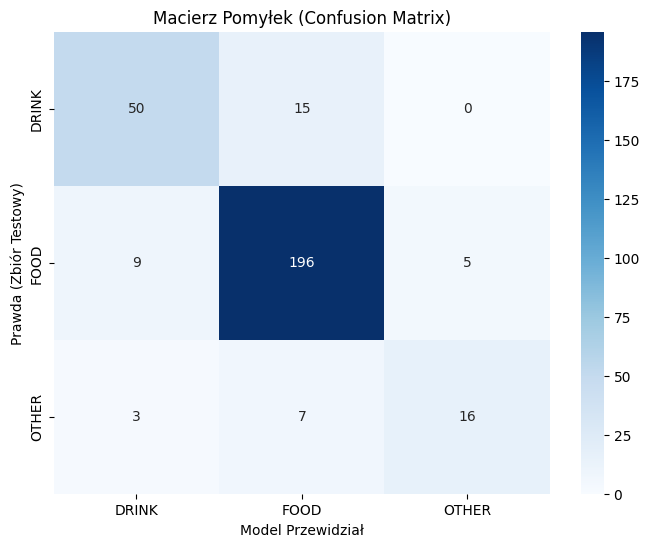

In [35]:
# Raport klasyfikacji
distilbert_model_augmented.plot_confusion_matrix()

In [36]:
# Zapisanie modelu
distilbert_model_augmented.save_model("./Models/distilbert_augmented")

Model zapisany w folderze: ./Models/distilbert_augmented


Analiza wyników modelu trenowanego na augmentowanych danych treningowych i porównanie z modelu trenowanego na oryginalnych danych treningowych:  
Augmentacja danych treningowych poprawiła wyniki modelu, ale Validation Loss mocno wzrósł, co sugeruje przeuczenie modelu.

1. Porównianie recall i F1 score
- DRINK wzrósł z 71% na 77% co poprawiło największy problem poprzedniego modelu
- FOOD spadł o 1% z 94% na 93% co jest do akceptacji
- OTHER wzrosł z 58% na 62% co jest do akceptacji
- F1 score wzrósł o 1-3%

2. Wzrost Validation Loss do 0.88 przy epoce 8 (z najlepszym wynikiem F1 score) przy Training Loss 0.025 pokazuje, że Model nauczył się augmentacji na pamięć.

3. Dla kategorii Drink wzrósł recall o 6% ale spadł precision o 4% co sugeruje, że model odważniej klasyfikował Drink, kosztem popełnienia większej ilości błędów. Jest to akceptowalne, bo zależy nam na większej liczbie poprawnych klasyfikacji Drink.

Wnioski po porównaniu modelu trenowanego na augmentowanych danych treningowych z modelem trenowanym na oryginalnych danych treningowych:
Augmentacja poprawiła główne wyniki (Accuracy i F1 score), ale sprawiła że model jest przeuczony. Podejrzewam, że potrzeba większej liczby prawdziwych danych treningowych lub zastosowania augmentacji semantycznej, np. przez ręczne dodanie danych lub wykorzystanie LLMów do generowania augmentacji.  
Na ten moment najlepszym modelem jest model trenowany na augmentowanych danych z epoki 8.  

### 7. Wytrenowanie pełnego modelu wielojęzycznego *xlm-roberta-base* na danych augmentowanych i porównanie wyników z modelem *distilbert-base-multilingual-cased*.

In [37]:
# Etykiety
labels_map = {"DRINK": 0, "FOOD": 1, "OTHER": 2}

# Inicjalizacja modelu
xlm_model = ModelTrainer(
    model_name="xlm-roberta-base",
    num_epochs=10,
    batch_size=16,
    train_file="csv_files/train_augmented.csv",
    test_file="csv_files/test.csv",
    labels_map=labels_map
)

In [38]:
# Tokenizacja danych
xlm_model.tokenize_data()

Map:   0%|          | 0/2067 [00:00<?, ? examples/s]

Map:   0%|          | 0/301 [00:00<?, ? examples/s]

In [39]:
# Trening modelu
xlm_model.train_model()

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Rozpoczynam trening...


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.610071,0.774086,0.657271
2,No log,0.585657,0.774086,0.688621
3,No log,0.437145,0.867110,0.752314
4,0.454900,0.654497,0.843854,0.742283
5,0.454900,0.513698,0.893688,0.782725
6,0.454900,0.620391,0.873754,0.787009
7,0.454900,0.674038,0.887043,0.807104
8,0.123100,0.620665,0.903654,0.809753
9,0.123100,0.636273,0.906977,0.837404
10,0.123100,0.665186,0.900332,0.807312


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\wolkt\AppData\R


Ewaluacja końcowa na zbiorze testowym:


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'epoch': 10.0,
 'eval_accuracy': 0.9069767441860465,
 'eval_f1': 0.8374036842786844,
 'eval_loss': 0.636272668838501,
 'eval_runtime': 9.6288,
 'eval_samples_per_second': 31.26,
 'eval_steps_per_second': 1.973}


C:\Users\wolkt\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



=== SZCZEGÓŁOWY RAPORT KLASYFIKACJI ===
              precision    recall  f1-score   support

       DRINK       0.87      0.85      0.86        65
        FOOD       0.92      0.96      0.94       210
       OTHER       0.84      0.62      0.71        26

    accuracy                           0.91       301
   macro avg       0.88      0.81      0.84       301
weighted avg       0.90      0.91      0.90       301



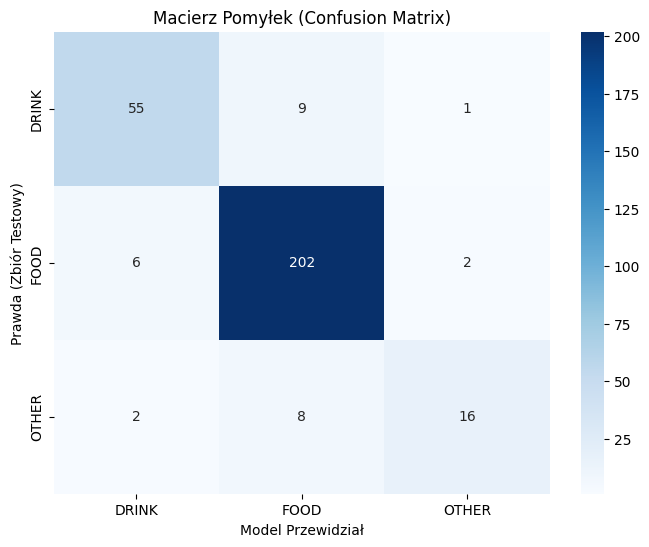

In [40]:
# Raport klasyfikacji
xlm_model.plot_confusion_matrix()

In [41]:
# Zapisanie modelu
xlm_model.save_model("./Models/xlm_model_augmented")

Model zapisany w folderze: ./Models/xlm_model_augmented


Analiza danych modelu XLM-Roberta na trenowanego na danych augmentowanych.  
Zmiana modelu na większy, któy lepiej radzi sobie z wielojęzycznością pozwoliła osiągnąć Accuracy na poziomie 90%, przy zadowalającym wyniku F1 score 83%.

1. Porównanie recall z modelem 2:
- DRINK 77% -> 85% (znaczący wzrost o 8%)
- FOOD 93% -> 96% (znaczący wzrost o 3%)
- OTHER 62% -> 62% (brak zmiany)

2. Validation Loss
Rośnie od 3 epoki z 0.43 do 0.63 w 9 epoce ale jest to dużo łagodniesze niż w poprzednich modelach. Pokazuje to, że większy model lepiej radzi sobie z Overfittingiem.

3. Wysoka skuteczność w klasie Food
Precision 92% i Recall 96% są bardzo wysokie.

### 8. Porównanie modeli i podsumowanie

Zestawienie najlepszych wyników wszystkich 3 modeli:  
1. Główne metryki oceny modelu

Model|Training Loss|Validation Loss|Accuracy|F1
---|---|---|---|---
DistilBERT Baseline|0.321600|0.604517|0.860465|0.777154
DistilBERT Augmented|0.025200|0.841904|0.870432|0.794713
TrXLM-RoBERTa Augmented|0.123100|0.636273|0.906977|0.837404

2. Szczegółowe raporty klasyfikacji

<table>
  <tr>
    <th>category</th><th>precision</th><th>recall</th><th>f1-score</th><th>support</th>
  </tr>
  <tr>
    <td colspan="5"><strong>Model DistilBERT Baseline</strong></td>
  </tr>
  <tr><td>DRINK</td><td>0.85</td><td>0.71</td><td>0.77</td><td>65</td></tr>
  <tr><td>FOOD</td><td>0.87</td><td>0.94</td><td>0.91</td><td>210</td></tr>
  <tr><td>OTHER</td><td>0.75</td><td>0.58</td><td>0.65</td><td>26</td></tr>
    <tr>
    <td colspan="5"><strong>Model DistilBERT Augmented</strong></td>
  </tr>
  <tr><td>DRINK</td><td>0.81</td><td>0.77</td><td>0.79</td><td>65</td></tr>
  <tr><td>FOOD</td><td>0.90</td><td>0.93</td><td>0.92</td><td>210</td></tr>
  <tr><td>OTHER</td><td>0.76</td><td>0.62</td><td>0.68</td><td>26</td></tr>
    <tr>
    <td colspan="5"><strong>Model XLM-RoBERTa Augmented</strong></td>
  </tr>
  <tr><td>DRINK</td><td>0.87</td><td>0.85</td><td>0.86</td><td>65</td></tr>
  <tr><td>FOOD</td><td>0.92</td><td>0.96</td><td>0.94</td><td>210</td></tr>
  <tr><td>OTHER</td><td>0.84</td><td>0.62</td><td>0.71</td><td>26</td></tr>
</table>

**Podsumowanie:**
1. Model 1 (Distilbert): Ma przyzwoitą dokładność (86%) ale z powodu niezbalansowania danych, nie radził sobie z klasyfikacją innych kategorii niż Food.
2. Model 2 (Distilbert z augmentacją): Augmentacja znacząco poprawiła klasyfikowanie napojów, ale widać że jest mocno przeuczony (Validation Loss = 0.84).
3. Model 3 (XLM z augmentacją): Zastosowanie większego modelu znacząco zwiększyło dokładność i pozwoliło zapobiec przeuczaniu.
4. Najsłabsze wyniki są w kategorii Other. Zmiana modelu nie polepszyła Recall co sugeruje, że należy zwiększyć ilość danych w tej kategorii.
5. Zastosowana augmentacja syntaktyczna (dodawanie prefiksów i sufiksów) działa, ale równocześnie powoduje overfitting. Prawdopodobnie lepsza byłaby augmentacja semantyczna przy użyciu LLMów.
6. Dostrajanie parametrów mogłoby dodać dodatkowe kilka procent. Można spróbować zmiany parametrów w TrainingArguments:
- weight_decay z 0.01 na 0.05 lub 0.1 - lepsza regulacja
- learning_rate z 2e-5 na 1e-5 - wolniejsze uczenie się modelu
- label_smoothing_factor=0.1 - powinna poprawić overfitting
7. Można dodać sztywne reguły dla znanych danych, np używając regex ("Tax" -> Other)


### Kod do wczytania modelu i sprawdzenia wyników

In [ ]:
loaded_trainer = ModelTrainer(
    model_name="",  # Zostanie nadpisane przez metodę load_saved_model
    num_epochs=1,
    batch_size=16,
    train_file="./csv_files/train_augmented.csv",
    test_file="./csv_files/test.csv",
    labels_map={"DRINK": 0, "FOOD": 1, "OTHER": 2}
)

# loaded_trainer.load_saved_model("./Models/distilbert_model_no_augmentation")
# loaded_trainer.load_saved_model("./Models/distilbert_augmented")
loaded_trainer.load_saved_model("./Models/xlm_model_augmented")

loaded_trainer.plot_confusion_matrix()

### Kod do pobawienia się modelem

In [44]:
# 1. Ścieżka do zapisanego modelu
saved_model_path = "./Models/xlm_model_augmented"

# 2. Załaduj pipeline
classifier = pipeline("text-classification", model=saved_model_path, tokenizer=saved_model_path)

# 3. Przetestuj na własnych przykładach
test_cases = [
    "Coca Cola Zero",              # Oczywisty napój
    "Nasi Goreng Spesial",         # Oczywiste jedzenie
    "Plastic Bag Small",           # Inne
    "Ice Cream Chocolate",         # Podchwytliwe (ma 'Ice') - ciekawe co zrobi?
    "Hot Spicy Chicken",           # Podchwytliwe (ma 'Hot') - ciekawe co zrobi?
    "Schabowy",                    # Polska nazwa
    "Service Charge 5%",           # Opłata
    "asdfqwerty"                   # losowe znaki
]

print("-" * 60)
print(f" Wyniki działania modelu załadowanego z: {saved_model_path}")
print("-" * 60)

for item in test_cases:
    result = classifier(item)[0]
    label = result['label']
    score = result['score']
    
    icon = "❓"
    if "FOOD" in label: icon = "🍔"
    elif "DRINK" in label: icon = "🥤"
    elif "OTHER" in label: icon = "🧾"
    
    print(f"{icon} '{item}' \n   -> Kategoria: {label} (Pewność: {score:.1%})\n")

Device set to use cpu


------------------------------------------------------------
 Wyniki działania modelu załadowanego z: ./Models/xlm_model_augmented
------------------------------------------------------------
🥤 'Coca Cola Zero' 
   -> Kategoria: DRINK (Pewność: 100.0%)

🍔 'Nasi Goreng Spesial' 
   -> Kategoria: FOOD (Pewność: 100.0%)

🧾 'Plastic Bag Small' 
   -> Kategoria: OTHER (Pewność: 100.0%)

🍔 'Ice Cream Chocolate' 
   -> Kategoria: FOOD (Pewność: 99.9%)

🍔 'Hot Spicy Chicken' 
   -> Kategoria: FOOD (Pewność: 100.0%)

🍔 'Schabowy' 
   -> Kategoria: FOOD (Pewność: 100.0%)

🧾 'Service Charge 5%' 
   -> Kategoria: OTHER (Pewność: 100.0%)

🍔 'asdfqwerty' 
   -> Kategoria: FOOD (Pewność: 99.9%)

